In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('student_performance_dataset.csv')

In [3]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [5]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [6]:
df.nunique()

,0
student_id,1000
gender,2
study_time_hours,70
attendance_percent,327
sleep_hours,65
parental_education,4
internet_access,2
extracurricular_activities,2
part_time_job,2
previous_grade,434


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


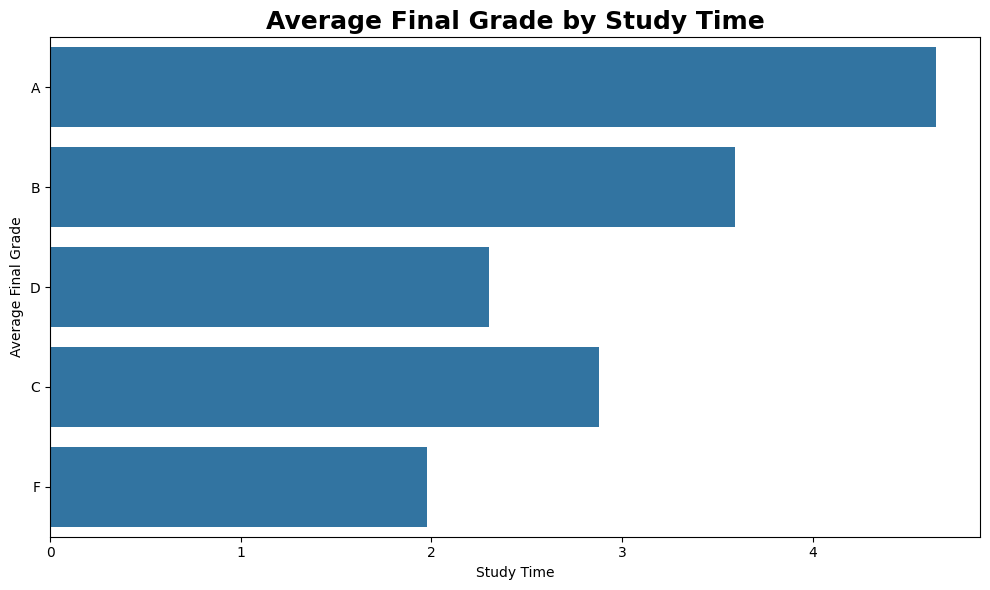

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='study_time_hours',
    y='final_grade',
    errorbar=None
)

plt.title(
    'Average Final Grade by Study Time',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Study Time')
plt.ylabel('Average Final Grade')

plt.tight_layout()
plt.show()

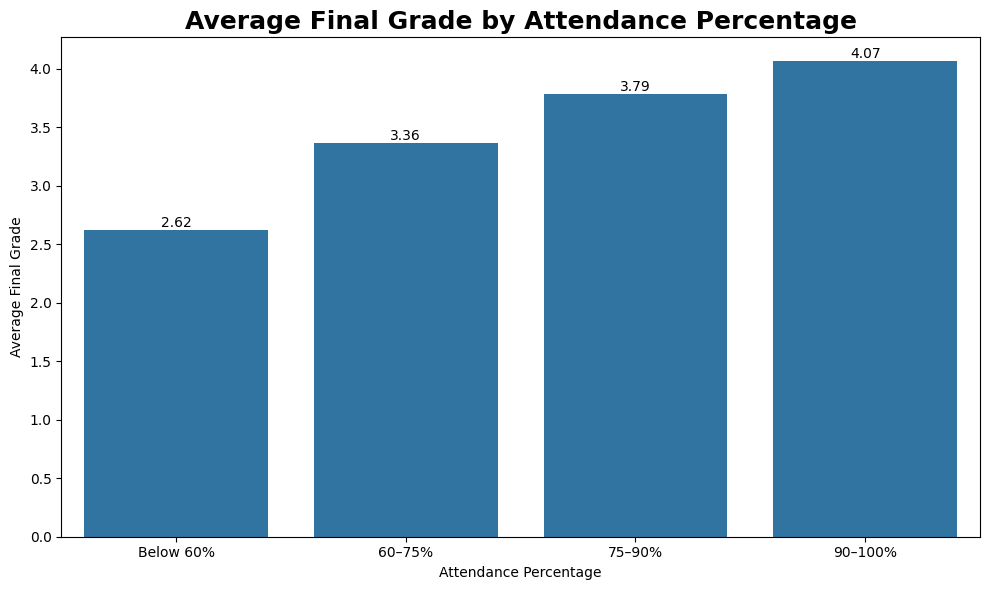

In [14]:
df['Attendance_Group'] = pd.cut(
    df['attendance_percent'],
    bins=[0, 60, 75, 90, 100],
    labels=['Below 60%', '60–75%', '75–90%', '90–100%']
)

# Map final_grade to numerical values for averaging
grade_mapping = {'A': 5, 'B': 4, 'C': 3, 'D': 2, 'F': 1}
df['final_grade_numeric'] = df['final_grade'].map(grade_mapping)

attendance_grade = (
    df.groupby('Attendance_Group', observed=False)['final_grade_numeric']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=attendance_grade,
    x='Attendance_Group',
    y='final_grade_numeric',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    'Average Final Grade by Attendance Percentage',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Attendance Percentage')
plt.ylabel('Average Final Grade')

plt.tight_layout()
plt.show()

## 💡 Insight 1: Study Time and Attendance vs Final Grade

As a principal, the analysis examines whether students' academic performance is associated with their **study time** and **attendance**.

The study-time analysis shows that students in the **A grade category** have the highest average study time, while students in the **F grade category** have the lowest average study time. This indicates an association between greater study time and better academic performance, although the analysis does not prove that study time alone causes higher grades.

The supporting analysis of attendance shows an even clearer pattern. Students with **below 60% attendance** have an average final grade of **2.62**, while students with **60–75% attendance** average **3.36**. This increases to **3.79** for students with **75–90% attendance** and reaches **4.07** among students with **90–100% attendance**.

Overall, the results suggest that **consistent attendance and higher study time are associated with better academic performance**. From an academic management perspective, encouraging regular attendance and effective study habits could be useful strategies for improving student outcomes.

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   student_id                  1000 non-null   int64   
 1   gender                      1000 non-null   object  
 2   study_time_hours            1000 non-null   float64 
 3   attendance_percent          1000 non-null   float64 
 4   sleep_hours                 1000 non-null   float64 
 5   parental_education          898 non-null    object  
 6   internet_access             1000 non-null   object  
 7   extracurricular_activities  1000 non-null   object  
 8   part_time_job               1000 non-null   object  
 9   previous_grade              1000 non-null   float64 
 10  final_exam_score            1000 non-null   float64 
 11  final_grade                 1000 non-null   object  
 12  Attendance_Group            1000 non-null   category
 13  final_grade_numeric

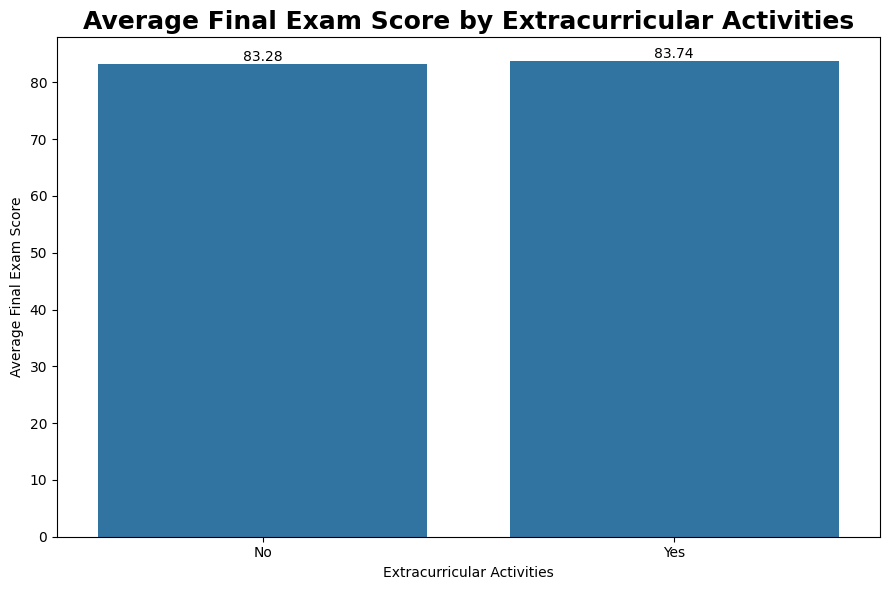

In [16]:
extra_activity = (
    df.groupby('extracurricular_activities')['final_exam_score']
      .mean()
      .reset_index()
)

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=extra_activity,
    x='extracurricular_activities',
    y='final_exam_score',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    'Average Final Exam Score by Extracurricular Activities',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Extracurricular Activities')
plt.ylabel('Average Final Exam Score')

plt.tight_layout()
plt.show()

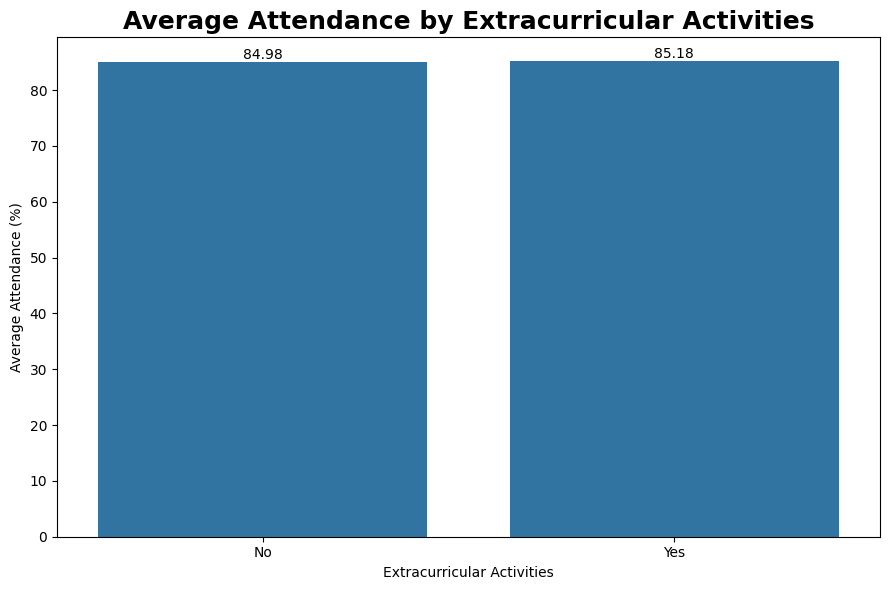

In [17]:
activity_attendance = (
    df.groupby('extracurricular_activities')['attendance_percent']
      .mean()
      .reset_index()
)

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=activity_attendance,
    x='extracurricular_activities',
    y='attendance_percent',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    'Average Attendance by Extracurricular Activities',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Extracurricular Activities')
plt.ylabel('Average Attendance (%)')

plt.tight_layout()
plt.show()

## 💡 Insight 2: Extracurricular Activities vs Academic Performance

The analysis examined whether participation in extracurricular activities is associated with better academic performance.

Students involved in extracurricular activities achieved an average final exam score of **83.74**, compared with **83.28** among students who did not participate. This represents only a small difference, suggesting that extracurricular participation alone does not have a strong association with final exam performance in this dataset.

The supporting analysis of attendance shows a similar pattern. Students participating in extracurricular activities had an average attendance of **85.18%**, while students without extracurricular activities had an average attendance of **84.98%**. The difference is extremely small.

Overall, the results suggest that **extracurricular participation does not appear to be a major differentiating factor in academic performance or attendance** within this dataset. This indicates that other factors may play a more important role in determining student outcomes.

In [19]:
df['parental_education'].unique()

array(['Bachelors', 'High School', nan, 'Masters', 'PhD'], dtype=object)

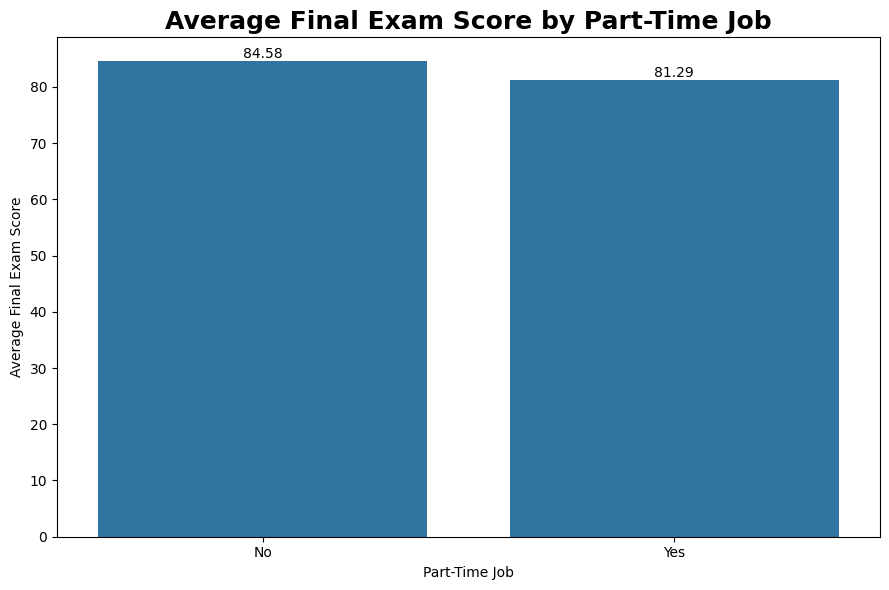

In [21]:
part_time = (
    df.groupby('part_time_job')['final_exam_score']
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=part_time,
    x='part_time_job',
    y='final_exam_score',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    'Average Final Exam Score by Part-Time Job',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Part-Time Job')
plt.ylabel('Average Final Exam Score')

plt.tight_layout()
plt.show()

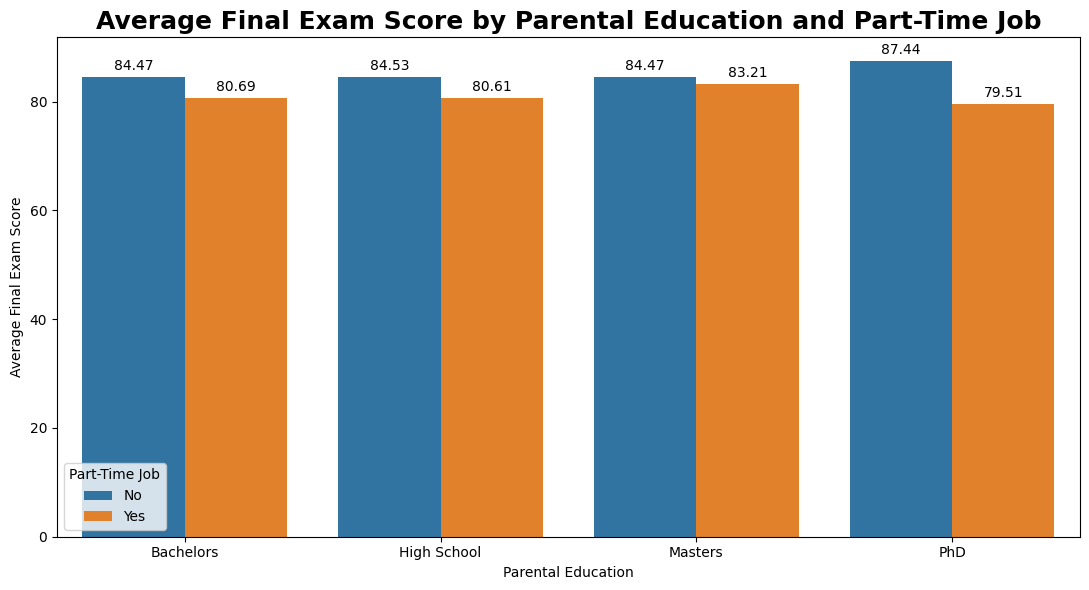

In [20]:
# Remove missing parental education values
temp = df.dropna(subset=['parental_education'])

support_data = (
    temp.groupby(['parental_education', 'part_time_job'])['final_exam_score']
        .mean()
        .reset_index()
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=support_data,
    x='parental_education',
    y='final_exam_score',
    hue='part_time_job',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title(
    'Average Final Exam Score by Parental Education and Part-Time Job',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Parental Education')
plt.ylabel('Average Final Exam Score')
plt.legend(title='Part-Time Job')

plt.tight_layout()
plt.show()

## 💡 Insight 3: Part-Time Jobs and Academic Performance

The analysis examines whether having a part-time job is associated with students' academic performance and whether this pattern changes across different levels of parental education.

Overall, students **without a part-time job** achieved a higher average final exam score of **84.58**, compared with **81.29** for students who had a part-time job. This suggests that students with part-time jobs tend to have slightly lower academic performance in this dataset.

The supporting analysis shows that this pattern is visible across most parental education groups. For example, among students whose parents have a **Bachelor's degree**, the average score is **84.47** for students without a part-time job compared with **80.69** for those with one. A similar difference can be observed for students with parents having a **High School, Master's, and PhD** education.

Interestingly, the gap is particularly large among students whose parents have a **PhD**, where students without a part-time job average **87.44**, compared with **79.51** among students with a part-time job.

Overall, the results suggest an association between **part-time employment and lower academic performance**, and this pattern remains visible across different parental education levels. However, the analysis does not establish that having a part-time job directly causes lower scores, as other factors may also influence student performance.

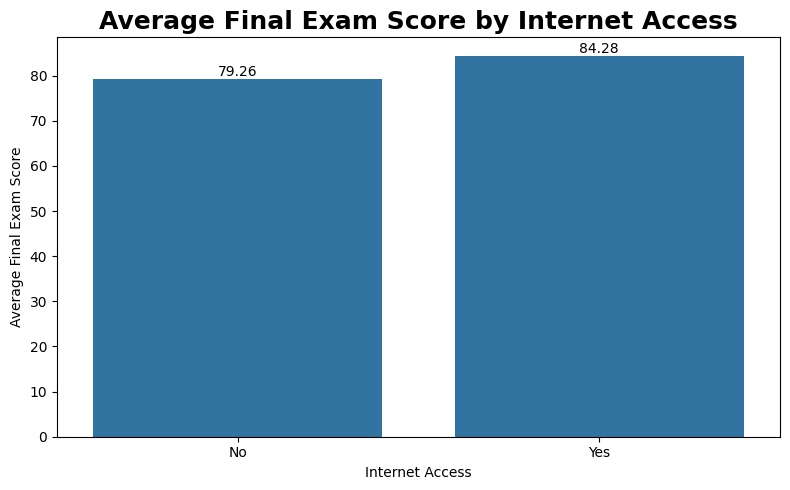

In [25]:
internet_score = (
    df.groupby('internet_access')['final_exam_score']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=internet_score,
    x='internet_access',
    y='final_exam_score',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    'Average Final Exam Score by Internet Access',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Internet Access')
plt.ylabel('Average Final Exam Score')

plt.tight_layout()
plt.show()

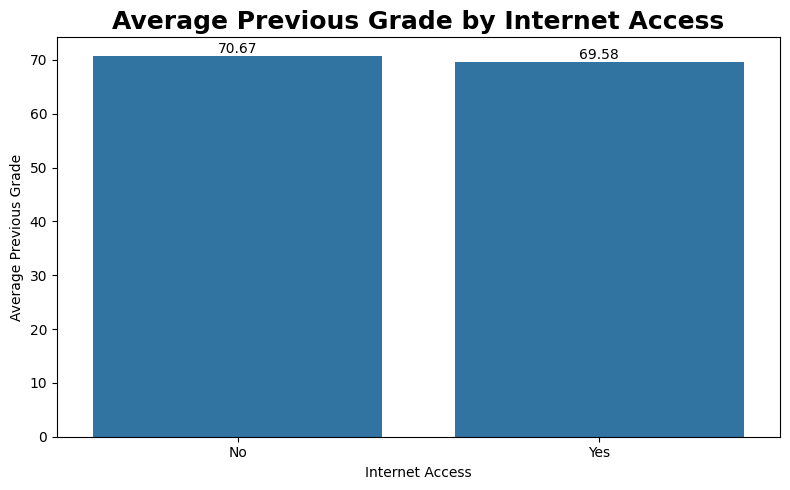

In [27]:
internet_previous = (
    df.groupby('internet_access')['previous_grade']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=internet_previous,
    x='internet_access',
    y='previous_grade',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    'Average Previous Grade by Internet Access',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Internet Access')
plt.ylabel('Average Previous Grade')

plt.tight_layout()
plt.show()

## 💡 Insight 4: Internet Access and Academic Performance

The analysis examines whether access to the internet is associated with students' academic performance.

Students with **internet access** achieved an average final exam score of **84.28**, compared with **79.26** among students without internet access, representing a difference of approximately **5 points**.

The supporting analysis of previous grades provides additional context. Students with internet access had a slightly lower average previous grade (**69.58**) compared with students without internet access (**70.67**). Despite starting with a slightly lower previous average, the internet-access group achieved a higher final exam score.

This suggests that internet access may be associated with better current academic performance in this dataset. However, the analysis does not establish that internet access directly causes higher scores, as other factors may also contribute to the difference.

Overall, the result highlights internet access as a potentially important factor worth considering when examining differences in student academic performance.

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   student_id                  1000 non-null   int64   
 1   gender                      1000 non-null   object  
 2   study_time_hours            1000 non-null   float64 
 3   attendance_percent          1000 non-null   float64 
 4   sleep_hours                 1000 non-null   float64 
 5   parental_education          898 non-null    object  
 6   internet_access             1000 non-null   object  
 7   extracurricular_activities  1000 non-null   object  
 8   part_time_job               1000 non-null   object  
 9   previous_grade              1000 non-null   float64 
 10  final_exam_score            1000 non-null   float64 
 11  final_grade                 1000 non-null   object  
 12  Attendance_Group            1000 non-null   category
 13  final_grade_numeric

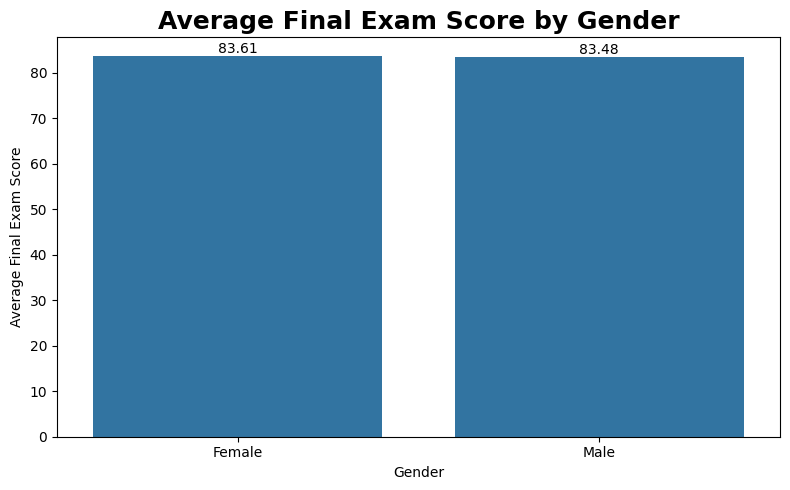

In [32]:
gender_score = (
    df.groupby('gender')['final_exam_score']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=gender_score,
    x='gender',
    y='final_exam_score',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    'Average Final Exam Score by Gender',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Gender')
plt.ylabel('Average Final Exam Score')

plt.tight_layout()
plt.show()

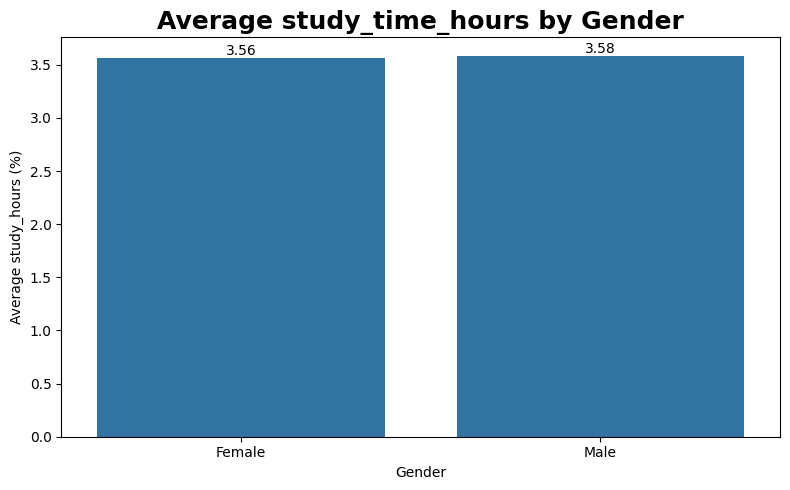

In [33]:
gender_attendance = (
    df.groupby('gender')['study_time_hours']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=gender_attendance,
    x='gender',
    y='study_time_hours',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    'Average study_time_hours by Gender',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Gender')
plt.ylabel('Average study_hours (%)')

plt.tight_layout()
plt.show()

## 💡 Insight 5: Gender and Academic Performance

The analysis examines whether academic performance and study habits differ between male and female students.

The average final exam scores are almost identical, with **female students scoring 83.61** and **male students scoring 83.48**. The difference is only **0.13 points**, indicating very little variation in academic performance between the two groups.

The supporting analysis of study time shows a similar pattern. Female students study for an average of **3.56 hours**, while male students study for approximately **3.58 hours** per day. The difference is only **0.02 hours**, showing that study habits are also very similar.

Overall, the results suggest that **gender does not appear to be a major differentiating factor in either study time or final exam performance** in this dataset.

This finding is important because it shows that academic performance is likely influenced more by other factors than by gender alone.

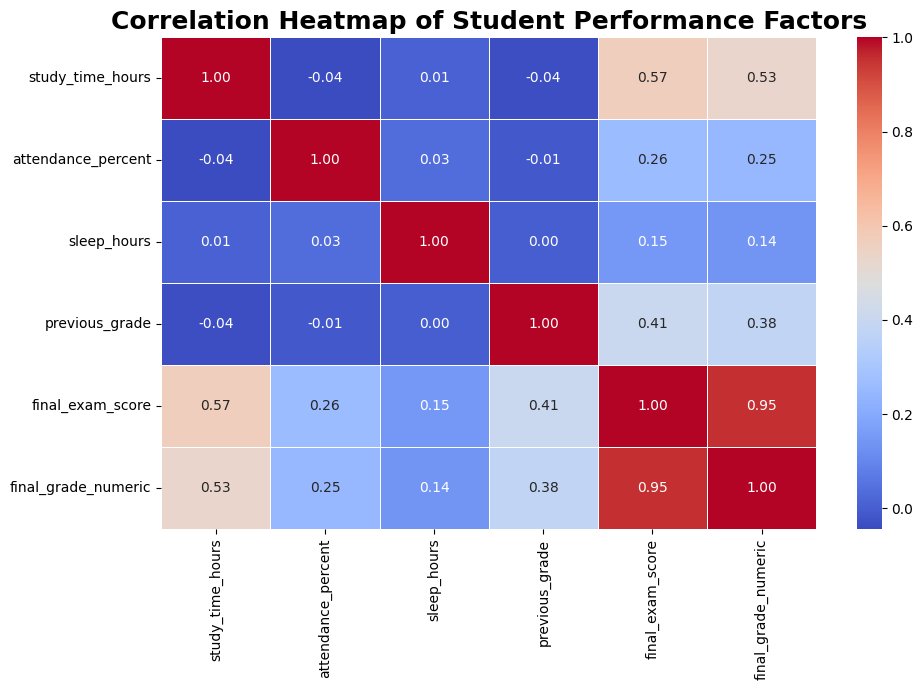

In [34]:
# Select numerical columns for correlation analysis

numeric_cols = [
    'study_time_hours',
    'attendance_percent',
    'sleep_hours',
    'previous_grade',
    'final_exam_score',
    'final_grade_numeric'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap of Student Performance Factors',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## 🏁 Conclusion

This Exploratory Data Analysis examined different factors that may be associated with student academic performance.

### Key Findings

1. **Study Time & Attendance**
   - Students with higher attendance showed progressively higher average final grades.
   - Students in the 90–100% attendance group achieved an average final grade of **4.07**, compared with **2.62** for students below 60% attendance.
   - Study time also showed differences across final-grade categories.

2. **Part-Time Jobs**
   - Students without part-time jobs achieved an average final exam score of **84.58**, compared with **81.29** for students with part-time jobs.
   - The difference was visible across different parental education levels, suggesting that students balancing work and studies may require additional academic support.

3. **Internet Access**
   - Students with internet access achieved an average final exam score of **84.28**, compared with **79.26** for students without internet access.
   - Interestingly, the internet-access group had a slightly lower average previous grade, suggesting that the current performance difference cannot simply be explained by stronger previous performance.

4. **Gender**
   - Academic performance was almost identical between male and female students.
   - Female students had an average final exam score of **83.61**, while male students scored **83.48**.
   - Study time was also nearly identical, at **3.56 hours** for females and **3.58 hours** for males.
   - Therefore, gender does not appear to be a major differentiating factor in this dataset.

5. **Correlation Analysis**
   - The final correlation heatmap provides an overall view of relationships between study habits, attendance, previous performance, and final exam performance.
   - It helps identify which numerical variables have stronger associations with student outcomes and which have relatively weak relationships.

### Overall Conclusion

The analysis suggests that **attendance, study habits, previous academic performance, internet access, and part-time employment are useful factors to investigate when understanding student performance**.

Among the analyzed factors, attendance shows a particularly clear pattern with final grades, while students with internet access also show higher average final exam scores.

At the same time, gender shows almost no meaningful difference in either study time or final exam performance.

These findings can help educational institutions identify students who may benefit from **academic support, better attendance monitoring, digital learning resources, and support for students balancing work with education**.

However, these findings represent **associations rather than causal relationships**. Further statistical analysis would be required to determine whether these factors directly influence academic performance.